In [9]:
# Load
from pathlib import Path
import pandas as pd
from run_xgb_profile_prediction import DEFAULT_CONFIG, MorphologyData

# Profiles
morphology_data = MorphologyData(**DEFAULT_CONFIG)

# Predictions
prediction_paths = {
    (f'{model} {version}', group): Path(f'results/Fit {model} {group} {version}.parquet')
    for group in ('Abundance', 'GO', 'SC', 'Abundance+SC', 'GO+Abundance', 'GO+SC', 'All')
    for model in ('Linear Regression', 'Lasso', 'XGB') 
    for version in ('2024-06-18', '2024-04-26')
}

prediction_dfs = {
    key: pd.read_parquet(path)
    for key, path in prediction_paths.items()
    if path.exists()
}

/scratch/yuriy/morphology-prediction/skl-models/run_xgb_profile_prediction.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abundance_df.loc[:, 'Protein present'] = 1


In [10]:
# Total sum of squares in profiles
profile_tss = (
    (
        morphology_data.well_features_and_profiles[morphology_data.profile_columns]
        - morphology_data.well_features_and_profiles[morphology_data.profile_columns].mean(axis='index')
    ) ** 2
).sum(axis='index')

# Compute R squared
fit_rsquared = pd.concat(
    {
        name:
            1 - ((df - morphology_data.well_features_and_profiles[morphology_data.profile_columns])**2).sum(axis='index') / profile_tss
        for name, df in prediction_dfs.items()
    },
    names = ['Model', 'Group']
)

In [11]:
rsquared_df = fit_rsquared.sort_values(ascending=False).to_frame(name='R Squared')
rsquared_df.index.set_names(['Model', 'Group', 'Feature'], inplace=True)
rsquared_df.reset_index(inplace=True)

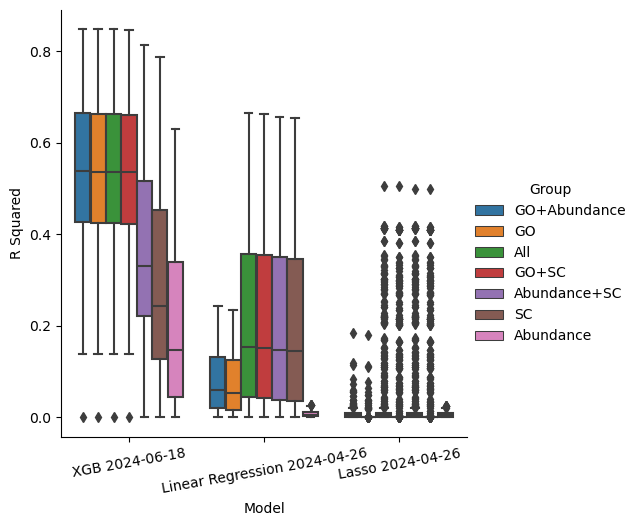

In [22]:
import seaborn as sns

g = sns.catplot(
    data=rsquared_df,
    hue='Group',
    y='R Squared',
    x='Model',
    kind='box',
    facet_kws={'margin_titles': True}
)
g.set_xticklabels(rotation=10)